In [2]:
%pip install matplotlib seaborn pandas numpy

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 1.5 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/9.3 MB 1.5 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.3 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.3 MB 1.3 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.3 MB 893.9 kB/s eta 0:00:09
   ------ --------------------------------- 1.6/9.3 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.3 MB 1.0 MB/s e


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\tech\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sns.set_theme(style="whitegrid")
%matplotlib inline

In [6]:
train = pd.read_parquet('../artifacts/train.parquet')

In [7]:
print(f" {train.shape[0]}")
print(f" {train.shape[1]}")
train.head()

 67533
 33


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,is_late
0,690a2092d1bf37549b9850423615d32a,761a4cbfcebc07e915349e3aee6db335,delivered,2018-06-20 19:25:54,2018-06-20 19:57:54,2018-06-21 12:24:00,2018-06-25 17:23:23,2018-07-13,ad8368b0fcaeaeff424018121c3d851d,85930,...,776.0,1.0,1250.0,21.0,21.0,15.0,86065.0,londrina,PR,0
1,af7d0849149bec7653f157d2a28d1f6d,50f88b1c1d1f4fec543bea69952deef2,delivered,2017-09-21 20:33:31,2017-09-21 20:44:18,2017-09-25 20:13:33,2017-10-04 19:11:38,2017-10-18,0c387284712d4d7047d46d5988ea7c0c,43700,...,2047.0,1.0,50.0,20.0,20.0,20.0,35170.0,coronel fabriciano,MG,0
2,389ac865e327bd982cf1101e0a77ff34,5ab6da4f0948f2079320f3ab48f44c5d,delivered,2018-07-06 21:06:43,2018-07-06 21:30:54,2018-07-10 11:21:00,2018-07-13 23:58:32,2018-07-30,f6e9bab0c1672b2133e95f1d91c4ccba,38110,...,319.0,4.0,250.0,16.0,2.0,20.0,5849.0,sao paulo,SP,0
3,214cc0f5b3a0461874dbbc915258bb54,bb0a7e8931e8e578f7bee85722bf921f,delivered,2018-06-16 17:02:59,2018-06-17 17:12:31,2018-06-19 12:28:00,2018-06-22 14:11:41,2018-07-12,324668abc6c8b8b720663badf85c30ea,13857,...,582.0,1.0,263.0,17.0,12.0,13.0,14840.0,guariba,SP,0
4,5834f2a1c94daee3cda85aa62af0a929,05d6dccf0ec00ec89c4462f9925903e1,delivered,2018-08-16 16:04:57,2018-08-16 16:15:32,2018-08-20 17:10:00,2018-08-22 17:32:30,2018-08-21,9b71a98cb4493166801d80c80e576ada,3612,...,1087.0,1.0,600.0,28.0,11.0,26.0,4850.0,sao paulo,SP,1


In [8]:
info_df = pd.DataFrame({
    'Data Type': train.dtypes,
    'Missing Values': train.isnull().sum(),
    'Missing Percentage (%)': (train.isnull().sum() / len(train)) * 100
})
print(info_df)

                                    Data Type  Missing Values  \
order_id                               object               0   
customer_id                            object               0   
order_status                           object               0   
order_purchase_timestamp               object               0   
order_approved_at                      object              11   
order_delivered_carrier_date           object               1   
order_delivered_customer_date  datetime64[ns]               0   
order_estimated_delivery_date  datetime64[ns]               0   
customer_unique_id                     object               0   
customer_zip_code_prefix                int64               0   
customer_city                          object               0   
customer_state                         object               0   
total_price                           float64               0   
total_freight                         float64               0   
total_items              

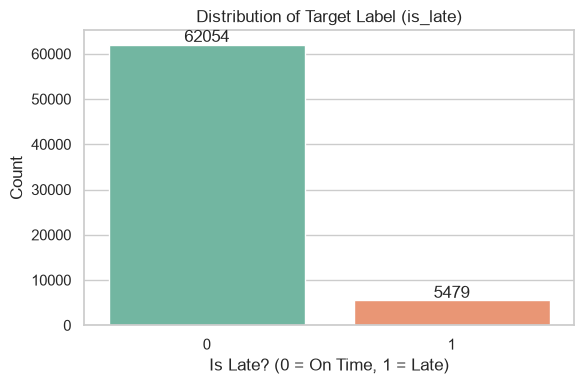

In [10]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train, x='is_late', hue='is_late', palette='Set2', legend=False)
plt.title('Distribution of Target Label (is_late)')
plt.xlabel('Is Late? (0 = On Time, 1 = Late)')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
os.makedirs('../artifacts/charts', exist_ok=True)
plt.savefig('../artifacts/charts/label_distribution.png')
plt.show()

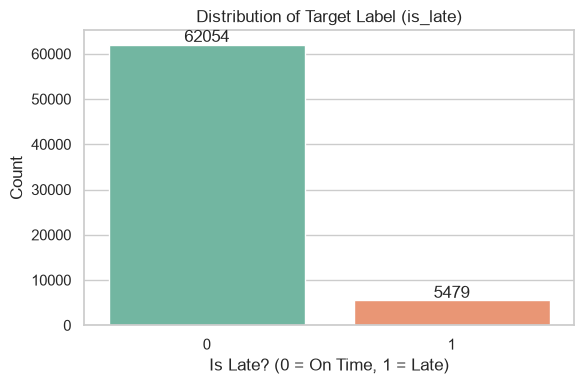

In [12]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train, x='is_late', hue='is_late', palette='Set2', legend=False)
plt.title('Distribution of Target Label (is_late)')
plt.xlabel('Is Late? (0 = On Time, 1 = Late)')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
os.makedirs('../artifacts/charts', exist_ok=True)
plt.savefig('../artifacts/charts/label_distribution.png')
plt.show()

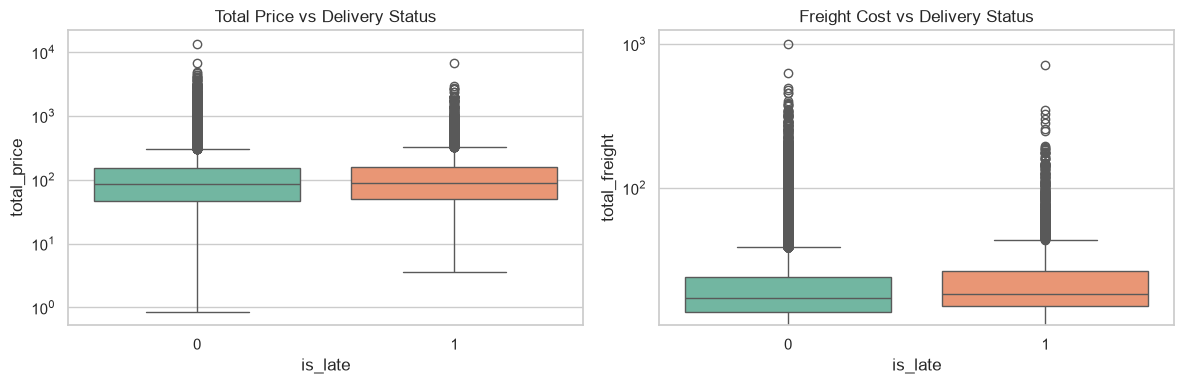

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=train, x='is_late', y='total_price', hue='is_late', ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Total Price vs Delivery Status')
axes[0].set_yscale('log')

sns.boxplot(data=train, x='is_late', y='total_freight', hue='is_late', ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('Freight Cost vs Delivery Status')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('../artifacts/charts/price_freight_vs_label.png')
plt.show()

In [15]:
findings = f"""=== MLOps Task 2: EDA Findings Summary ===
1. Data Shape: Train set contains {train.shape[0]} rows and {train.shape[1]} columns.
2. Target Imbalance: ~8% of orders are late, requiring specialized metrics (ROC-AUC, PR-AUC).
3. Missing Values: Found mainly in delivery timestamps for unfulfilled orders.
4. Numerical Features: Price and freight costs show strong skewness.
"""

In [16]:
with open('../artifacts/eda_findings.txt', 'w', encoding='utf-8') as f:
    f.write(findings)